In [12]:
from kad_functions.sql_data import get_sql_query

reservoir_levels_query = """
SELECT *
FROM pub.dimMetadata
WHERE CurveName LIKE '%hydro%'
"""

reservoir_level_curves = get_sql_query(reservoir_levels_query)

display(reservoir_level_curves)

,CurveId,CurveName,CurveIDAndName,CommodityCode,MeasureCategoryCode,MeasureCode,TradingContractCode,UnitCode,StatusCode,ProviderCode,...,ApprovedBy,SourceURL,ReportedToApprover,CreatedBy,CreatedOn,ModifiedBy,ModifiedOn,IsCustomTable,Sender,ScrapingDestinationStatus
0,25002,TEST-WATTSIGHT-tt np hydro ecmonthly °c cet mi...,25002 - TEST-WATTSIGHT-tt np hydro ecmonthly °...,N/A,WEATHER,TEMPERATURE,N/A,CELCIUS,FORECAST,INCOMMODITIES,...,N/A,None,0,IN-COMMODITIES\nkr,2023-05-09 12:41:55.503,IN-COMMODITIES\ForwardPowerProfiseeApi,2025-10-29 08:38:36.430,0,None,None
1,25003,TEST2-WATTSIGHT-tt np hydro ecmonthly °c cet m...,25003 - TEST2-WATTSIGHT-tt np hydro ecmonthly ...,N/A,WEATHER,TEMPERATURE,N/A,CELCIUS,FORECAST,INCOMMODITIES,...,N/A,None,0,IN-COMMODITIES\nkr,2023-05-09 12:41:55.503,IN-COMMODITIES\ForwardPowerProfiseeApi,2025-10-29 08:38:36.430,0,None,None
2,25004,TEST3-WATTSIGHT-tt np hydro ecmonthly °c cet m...,25004 - TEST3-WATTSIGHT-tt np hydro ecmonthly ...,N/A,WEATHER,TEMPERATURE,N/A,CELCIUS,FORECAST,INCOMMODITIES,...,N/A,None,0,IN-COMMODITIES\nkr,2023-05-09 12:41:55.503,IN-COMMODITIES\ForwardPowerProfiseeApi,2025-10-29 08:38:36.430,0,None,None
3,124590,UsPwrScania2008A.SYN.FRA-;FRA.FR;Hydro;Syn;D.1...,124590 - UsPwrScania2008A.SYN.FRA-;FRA.FR;Hydr...,POWER,PRODUCTION,OUTPUT,N/A,GWH,FORECAST,POINTCONNECT,...,N/A,None,1,IN-COMMODITIES\nkr,2023-03-12 15:12:09.197,IN-COMMODITIES\ForwardPowerProfiseeApi,2025-10-25 07:30:12.357,0,pointconnectscraper,None
4,125205,UsPwrScania2008A.SYN.FRA-;FRA.FR;Hydro;N;D.1;;...,125205 - UsPwrScania2008A.SYN.FRA-;FRA.FR;Hydr...,POWER,PRODUCTION,OUTPUT,N/A,GWH,NORMAL,POINTCONNECT,...,N/A,None,1,IN-COMMODITIES\nkr,2023-03-12 15:12:09.197,IN-COMMODITIES\ForwardPowerProfiseeApi,2025-10-25 07:30:12.357,0,None,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2920,1500029726,MAVIR_Ext_Net_Load_Trade_Settlement_Hydro_Run-...,1500029726 - MAVIR_Ext_Net_Load_Trade_Settleme...,None,None,None,None,None,ACTUAL,None,...,None,None,1,IN-COMMODITIES\bi,2026-03-05 14:07:54.143,IN-COMMODITIES\bi,2026-03-05 14:07:54.143,0,None,None
2921,1500029727,MAVIR_Ext_Net_Load_Trade_Settlement_Hydro_Pump...,1500029727 - MAVIR_Ext_Net_Load_Trade_Settleme...,None,None,None,None,None,ACTUAL,None,...,None,None,1,IN-COMMODITIES\bi,2026-03-05 14:07:54.713,IN-COMMODITIES\bi,2026-03-05 14:07:54.713,0,None,None
2922,1500030036,FP-EPSI-HYDROSTACK-FUELPRICE-PT,1500030036 - FP-EPSI-HYDROSTACK-FUELPRICE-PT,POWER,DAYAHEAD,PRICE,SPOT,EUR-MWH,FORECAST,FORWARDPOWER,...,None,None,1,IN-COMMODITIES\lan,2026-03-27 07:10:49.470,IN-COMMODITIES\lan,2026-03-27 07:10:49.470,0,None,None
2923,1500030037,FP-EPSI-HYDROSTACK-LARGEUNITCAPACITY-PT,1500030037 - FP-EPSI-HYDROSTACK-LARGEUNITCAPAC...,POWER,PRODUCTION,AVAILABLE-CAPACITY,N/A,MW,FORECAST,FORWARDPOWER,...,None,None,1,IN-COMMODITIES\lan,2026-03-27 07:10:49.470,IN-COMMODITIES\lan,2026-03-27 07:10:49.470,0,None,None


In [13]:
# Filter for curves that might represent reservoir levels/filling (not generation)
# Look for keywords: reservoir, filling, storage, level, STO, LVOL, water
level_keywords = reservoir_level_curves[
    reservoir_level_curves['CurveName'].str.contains(
        'reservoir|filling|storage|level|STO|LVOL|water|magasin',
        case=False, na=False
    )
].copy()

print(f"Curves with reservoir/storage/level keywords: {len(level_keywords)}")
display(level_keywords[['CurveId', 'CurveName', 'CountryCode']].sort_values('CurveName'))

Curves with reservoir/storage/level keywords: 417


,CurveId,CurveName,CountryCode
504,116267072,EEX.APGL.DEU;PWR;EEX;H.1;min.15;CET;APGL;DE;Hy...,DE
502,116267063,EEX.APGL.DEU;PWR;EEX;H.1;min.15;CET;APGL;DE;Hy...,DE
113,102238651,EEX.Pro.AvCap.DEU-AUT;PWR;EEX;PRO;Av.cap.;CET;...,DE
1366,910002964,ENAPPSYS_Production_DA_30Min_HYDRO-PUMPED-STOR...,GB
454,113956048,ENTSO-E.PRO.DEU.UNIT;PWR;ENTSOE;UTC;A;MW;H.1;1...,DE
...,...,...,...
687,143967829,PMTHydroStorage2010A.SYN.NRD;Pwr;PC;UTC;W.1;W....,SE
683,143967787,PMTHydroStorage2010A.SYN.NRD;Pwr;PC;UTC;W.1;W....,SE
681,143967774,PMTHydroStorage2010A.SYN.NRD;Pwr;PC;UTC;W.1;W....,SE
689,143967839,PMTHydroStorage2010A.SYN.NRD;Pwr;PC;UTC;W.1;W....,SE


In [14]:
import pandas as pd

# Norwegian reservoir level/filling curves specifically
no_reservoir = reservoir_level_curves[
    (reservoir_level_curves['CurveName'].str.contains('NO|NOR|Norway', case=False, na=False)) &
    (reservoir_level_curves['CurveName'].str.contains('reservoir|filling|storage|level|STO|LVOL|magasin', case=False, na=False))
].copy()

# Also check by CountryCode
no_reservoir2 = reservoir_level_curves[
    (reservoir_level_curves['CountryCode'] == 'NO') &
    (reservoir_level_curves['CurveName'].str.contains('reservoir|filling|storage|level|STO|LVOL|magasin', case=False, na=False))
]

no_all = pd.concat([no_reservoir, no_reservoir2]).drop_duplicates()
print(f"Norwegian reservoir/level curves: {len(no_all)}")
display(no_all[['CurveId', 'CurveName', 'CountryCode']].sort_values('CurveName'))

Norwegian reservoir/level curves: 167


,CurveId,CurveName,CountryCode
544,118207699,ENTSO-E.PRO.NOR.UNIT;PWR;ENTSOE;UTC;H.1;A;MW;1...,NO
580,118207735,ENTSO-E.PRO.NOR.UNIT;PWR;ENTSOE;UTC;H.1;A;MW;1...,NO
522,118207677,ENTSO-E.PRO.NOR.UNIT;PWR;ENTSOE;UTC;H.1;A;MW;1...,NO
531,118207686,ENTSO-E.PRO.NOR.UNIT;PWR;ENTSOE;UTC;H.1;A;MW;1...,NO
710,151953736,ENTSO-E.PRO.NOR.UNIT;PWR;ENTSOE;UTC;H.1;A;MW;1...,NO
...,...,...,...
686,143967818,PMTHydroStorage2010A.SYN.NRD;Pwr;PC;UTC;W.1;W....,NO
682,143967775,PMTHydroStorage2010A.SYN.NRD;Pwr;PC;UTC;W.1;W....,NO
688,143967830,PMTHydroStorage2010A.SYN.NRD;Pwr;PC;UTC;W.1;W....,NO
684,143967807,PMTHydroStorage2010A.SYN.NRD;Pwr;PC;UTC;W.1;W....,NO


In [15]:
# Exclude production/generation curves - focus on level/filling/volume data
no_levels = no_all[
    ~no_all['CurveName'].str.contains('PRO\.|PROD|PRODUCTION|Generation|UNIT', case=False, na=False)
].copy()

print(f"After excluding production curves: {len(no_levels)}")
for _, row in no_levels[['CurveId', 'CurveName']].iterrows():
    print(f"  {row['CurveId']:>12}  {row['CurveName']}")

After excluding production curves: 21
     143967775  PMTHydroStorage2010A.SYN.NRD;Pwr;PC;UTC;W.1;W.1;Res;Syn-N;TRE;GWh;;;;;NO2;NOR;;;;
     143967807  PMTHydroStorage2010A.SYN.NRD;Pwr;PC;UTC;W.1;W.1;Res;Syn-N;TRE;GWh;;;;;NO4;NOR;;;;
     143967817  PMTHydroStorage2010A.SYN.NRD;Pwr;PC;UTC;W.1;W.1;Res;Syn-N;TRE;GWh;;;;;NO5;NOR;;;;
     143967818  PMTHydroStorage2010A.SYN.NRD;Pwr;PC;UTC;W.1;W.1;Res;Syn-N;TRE;GWh;;;;;NO1;NOR;;;;
     143967830  PMTHydroStorage2010A.SYN.NRD;Pwr;PC;UTC;W.1;W.1;Res;Syn-N;TRE;GWh;;;;;NO3;NOR;;;;
     144079712  PMTHydroStorage2010A.ECENS.NRD;Pwr;PC;UTC;W.1;H.12;Res;F-N;TRE;GWh;;EC.Ens;AvgAcross;;NO3;NOR;;;;
     144079738  PMTHydroStorage2010A.ECENS.NRD;Pwr;PC;UTC;W.1;H.12;Res;F-N;TRE;GWh;;EC.Ens;AvgAcross;;NO2;NOR;;;;
     144079770  PMTHydroStorage2010A.ECENS.NRD;Pwr;PC;UTC;W.1;H.12;Res;F-N;TRE;GWh;;EC.Ens;AvgAcross;;NO1;NOR;;;;
     144079778  PMTHydroStorage2010A.ECENS.NRD;Pwr;PC;UTC;W.1;H.12;Res;F-N;TRE;GWh;;EC.Ens;AvgAcross;;NO4;NOR;;;;
     144079783  

## Norwegian Hydro Balance: Reservoir + Snow/Soil

Fetch weekly reservoir levels (NPS-HydroReservoir) and daily snow+soil reservoir energy (SRE from Scania model) for each Norwegian bidding zone, then aggregate to national totals.

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
from kad_functions.sql_data import get_sql_query

# --- Water Reservoir Levels ---
# Try PMTHydroStorage (Scania model) weekly reservoir content in GWh
# These are "Res;Syn-N;TRE;GWh" = Reservoir Synthetic (actuals), weekly
reservoir_curve_ids = {
    'NO1': 143967818,
    'NO2': 143967775,
    'NO3': 143967830,
    'NO4': 143967807,
    'NO5': 143967817,
}

reservoir_data = {}
for zone, cid in reservoir_curve_ids.items():
    q = f"""
    SELECT ValueDateUTC, ForecastDateUTC, Value
    FROM pub.Timeseries1_v02
    WHERE CurveId = {cid}
    AND ValueDateUTC >= '2015-01-01'
    """
    df = get_sql_query(q)
    df = df.sort_values('ForecastDateUTC').drop_duplicates(subset='ValueDateUTC', keep='last')
    df['ValueDateUTC'] = pd.to_datetime(df['ValueDateUTC'])
    df = df.set_index('ValueDateUTC').sort_index()
    reservoir_data[zone] = df['Value']
    print(f"Reservoir {zone}: {len(df)} points, {df.index.min().date()} to {df.index.max().date()}")

df_reservoir = pd.DataFrame(reservoir_data)
df_reservoir['NO_total'] = df_reservoir.sum(axis=1)

print(f"\nReservoir data shape: {df_reservoir.shape}")
display(df_reservoir.tail())

Reservoir NO1: 594 points, 2015-01-05 to 2026-05-18
Reservoir NO2: 594 points, 2015-01-05 to 2026-05-18
Reservoir NO3: 594 points, 2015-01-05 to 2026-05-18
Reservoir NO4: 594 points, 2015-01-05 to 2026-05-18
Reservoir NO5: 594 points, 2015-01-05 to 2026-05-18

Reservoir data shape: (594, 6)


,NO1,NO2,NO3,NO4,NO5,NO_total
ValueDateUTC,,,,,,
2026-04-20,-2371.99,-10309.81,-4206.48,1023.01,-6230.34,-22095.61
2026-04-27,-2788.79,-11049.42,-4197.04,1431.23,-6685.72,-23289.74
2026-05-04,-2874.42,-11683.47,-4165.68,1428.23,-6914.80,-24210.14
2026-05-11,-2014.50,-11197.84,-4068.02,1304.51,-6791.29,-22767.14
2026-05-18,-2010.72,-10861.12,-3804.60,1177.30,-6341.81,-21840.95


In [17]:
# --- Snow + Soil Reservoir Energy (SRE) ---
# Scania model synthetic/normal curves: daily GWh per bidding zone
sre_curve_ids = {
    'NO1': 101599348,
    'NO2': 101599333,
    'NO3': 101599359,
    'NO4': 104381668,
    'NO5': 104381694,
}

sre_data = {}
for zone, cid in sre_curve_ids.items():
    q = f"""
    SELECT ValueDateUTC, ForecastDateUTC, Value
    FROM pub.Timeseries1_v02
    WHERE CurveId = {cid}
    AND ValueDateUTC >= '2015-01-01'
    """
    df = get_sql_query(q)
    df = df.sort_values('ForecastDateUTC').drop_duplicates(subset='ValueDateUTC', keep='last')
    df['ValueDateUTC'] = pd.to_datetime(df['ValueDateUTC'])
    df = df.set_index('ValueDateUTC').sort_index()
    sre_data[zone] = df['Value']
    print(f"Snow/Soil {zone}: {len(df)} points, {df.index.min().date()} to {df.index.max().date()}")

df_sre = pd.DataFrame(sre_data)
df_sre['NO_total'] = df_sre.sum(axis=1)

print(f"\nSnow/Soil data shape: {df_sre.shape}")
display(df_sre.tail())

Snow/Soil NO1: 5844 points, 2015-01-01 to 2030-12-31
Snow/Soil NO2: 5844 points, 2015-01-01 to 2030-12-31
Snow/Soil NO3: 5844 points, 2015-01-01 to 2030-12-31
Snow/Soil NO4: 5844 points, 2015-01-01 to 2030-12-31
Snow/Soil NO5: 5844 points, 2015-01-01 to 2030-12-31

Snow/Soil data shape: (5844, 6)


,NO1,NO2,NO3,NO4,NO5,NO_total
ValueDateUTC,,,,,,
2030-12-27,6456.6724,10077.2715,4408.2793,5543.4922,7293.0313,33778.7467
2030-12-28,6501.9434,10192.9004,4459.4951,5604.9995,7372.7676,34132.1060
2030-12-29,6548.0508,10309.7480,4510.7925,5666.4067,7452.7227,34487.7207
2030-12-30,6594.8711,10428.1348,4562.1851,5727.7925,7533.1382,34846.1217
2030-12-31,6642.7646,10549.2725,4614.2231,5789.3604,7614.9604,35210.5810


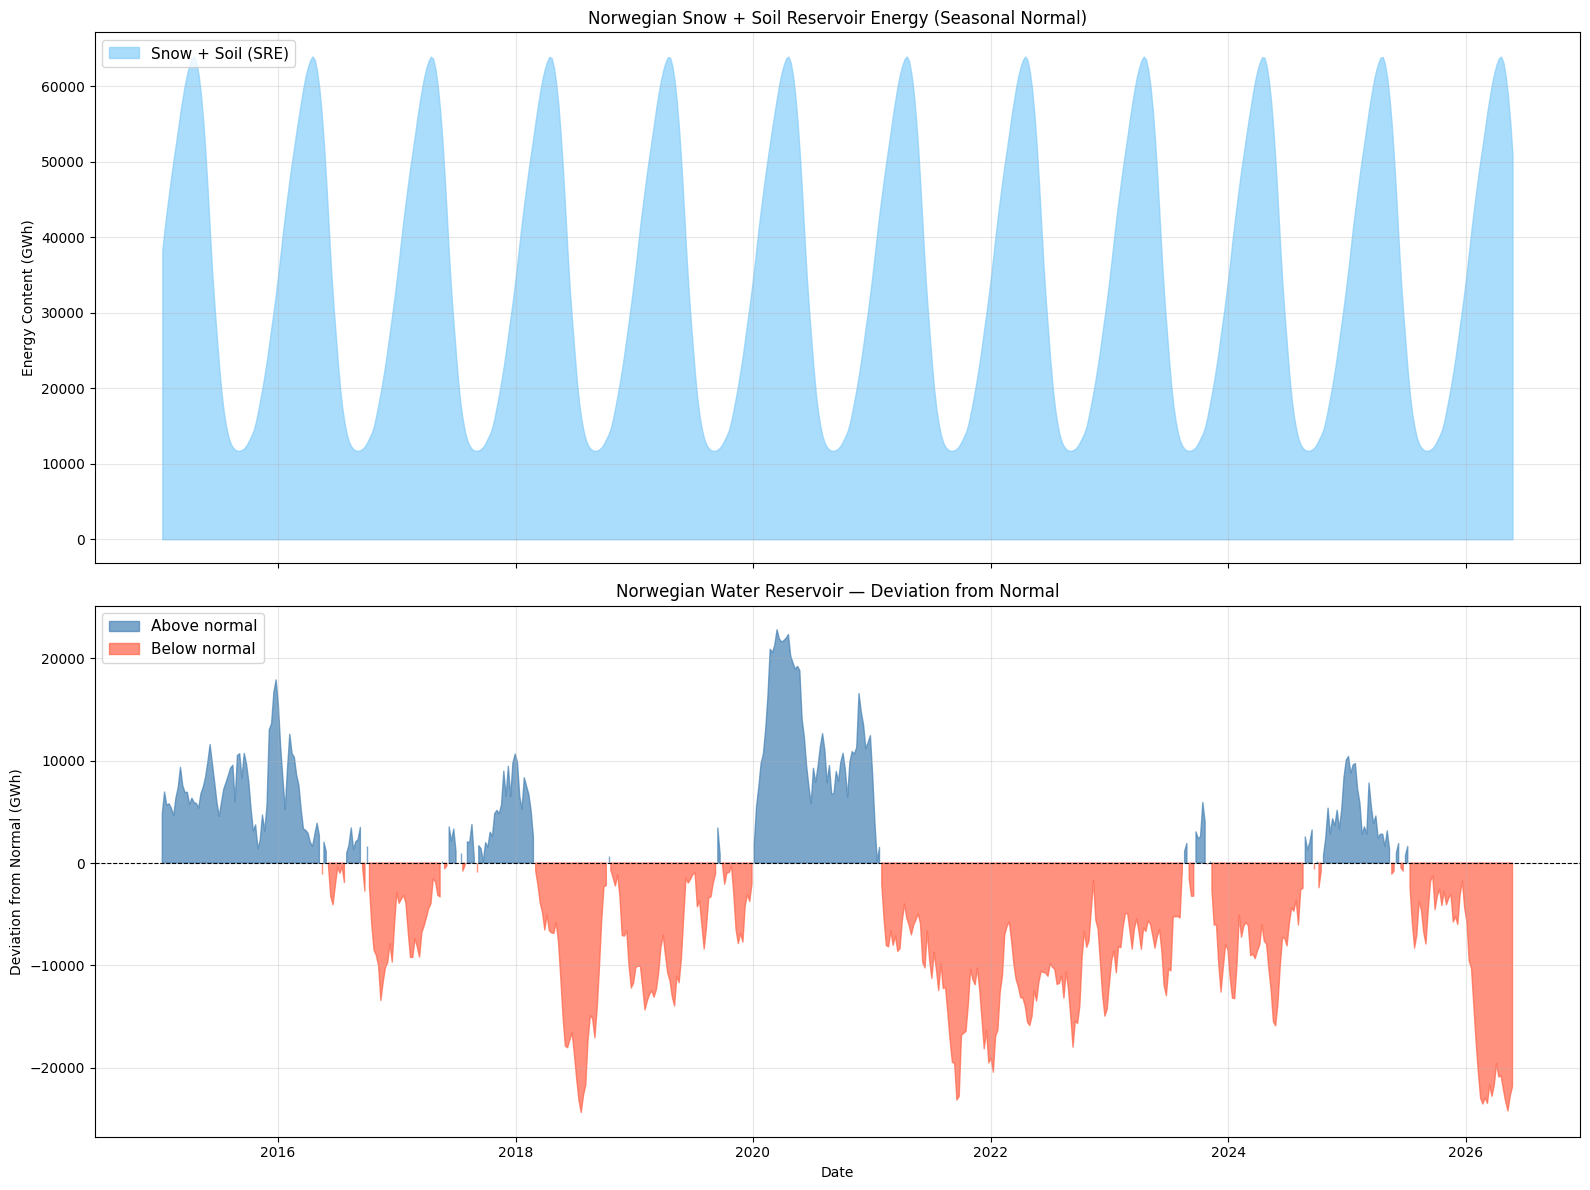


Latest values:
  Snow + Soil (SRE normal): 50,925 GWh
  Reservoir dev. from normal: -21,841 GWh


In [18]:
# --- Plot: Two panels ---
# Top: Snow/Soil (SRE) absolute levels showing seasonal accumulation/melt
# Bottom: Reservoir deviation from normal

# Resample snow/soil to weekly to align with reservoir data
sre_weekly = df_sre['NO_total'].resample('W').mean()
res_weekly = df_reservoir['NO_total'].resample('W').mean()

# Align on common index
combined = pd.DataFrame({
    'Reservoir (dev. from normal)': res_weekly,
    'Snow + Soil (SRE)': sre_weekly
}).dropna()

fig, axes = plt.subplots(2, 1, figsize=(16, 12), sharex=True)

# Top panel: Snow/Soil absolute levels
axes[0].fill_between(combined.index, 0, combined['Snow + Soil (SRE)'],
                     alpha=0.7, color='lightskyblue', label='Snow + Soil (SRE)')
axes[0].set_ylabel('Energy Content (GWh)')
axes[0].set_title('Norwegian Snow + Soil Reservoir Energy (Seasonal Normal)')
axes[0].legend(loc='upper left', fontsize=11)
axes[0].grid(True, alpha=0.3)

# Bottom panel: Reservoir deviation from normal
axes[1].fill_between(combined.index, 0, combined['Reservoir (dev. from normal)'],
                     where=combined['Reservoir (dev. from normal)'] >= 0,
                     alpha=0.7, color='steelblue', label='Above normal')
axes[1].fill_between(combined.index, 0, combined['Reservoir (dev. from normal)'],
                     where=combined['Reservoir (dev. from normal)'] < 0,
                     alpha=0.7, color='tomato', label='Below normal')
axes[1].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Deviation from Normal (GWh)')
axes[1].set_title('Norwegian Water Reservoir — Deviation from Normal')
axes[1].legend(loc='upper left', fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nLatest values:")
print(f"  Snow + Soil (SRE normal): {combined['Snow + Soil (SRE)'].iloc[-1]:,.0f} GWh")
print(f"  Reservoir dev. from normal: {combined['Reservoir (dev. from normal)'].iloc[-1]:,.0f} GWh")